In [1]:
import pandas as pd

from SCIKIT.Lesson9HyperparameterTuningwithGridsearchCV import param_grid

data = {
    "area": [
        800, 900, 1000, 1100, 1200,
        1300, 1400, 1500, 1600, 1700,
        1800, 1900, 2000, 2100, 2200,
        2300, 2400, 2500, 2600, 2700,
        2800, 2900, 3000, 3100, 3200
    ],

    "bedrooms": [
        1, 2, 2, 2, 3,
        3, 3, 3, 4, 4,
        4, 4, 4, 5, 5,
        5, 5, 5, 6, 6,
        6, 6, 7, 7, 7
    ],

    "age": [
        25, 22, 20, 18, 15,
        14, 12, 10, 9, 8,
        7, 6, 5, 5, 4,
        4, 3, 3, 2, 2,
        2, 1, 1, 1, 1
    ],

    "price": [
        120000, 135000, 150000, 160000, 175000,
        190000, 210000, 225000, 245000, 260000,
        280000, 295000, 315000, 340000, 360000,
        385000, 410000, 435000, 460000, 490000,
        520000, 550000, 590000, 630000, 680000
    ]
}

df = pd.DataFrame(data)

df

,area,bedrooms,age,price
0,800,1,25,120000
1,900,2,22,135000
2,1000,2,20,150000
3,1100,2,18,160000
4,1200,3,15,175000
5,1300,3,14,190000
6,1400,3,12,210000
7,1500,3,10,225000
8,1600,4,9,245000
9,1700,4,8,260000


In [3]:
X = df[[
    "area",
    "bedrooms",
    "age"
]]

y = df["price"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
print("X train shape:",X_train.shape)
print("y train shape:",y_train.shape)
print("X test shape:",X_test.shape)
print("y test shape:",y_test.shape)

X train shape: (20, 3)
y train shape: (20,)
X test shape: (5, 3)
y test shape: (5,)


In [8]:
from sklearn.ensemble import GradientBoostingRegressor
model=GradientBoostingRegressor(
    random_state=42

)


In [14]:
param_grid={
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [1, 2, 3, 4, 5],
    "learning_rate": [0.1, 0.2, 0.3, 0.4, 0.5],


}
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

In [15]:
grid_search.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.2, ...], 'max_depth': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose:

In [16]:
print("Best params:")
print(grid_search.best_params_)


Best params:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}


In [21]:
print(grid_search.best_estimator_)
best_model = grid_search.best_estimator_

print(best_model)

GradientBoostingRegressor(max_depth=4, n_estimators=300, random_state=42)
GradientBoostingRegressor(max_depth=4, n_estimators=300, random_state=42)


In [19]:
print("Best cv")
print(grid_search.best_score_)

Best cv
-625566311.1525099


In [20]:
best_cv_mse = -grid_search.best_score_

print("Best Cross-Validation MSE:", best_cv_mse)

Best Cross-Validation MSE: 625566311.1525099


In [22]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test R²:", r2)

Test MSE: 395746000.3320004
Test R²: 0.9866707308746379


In [23]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 19893.36573664699


In [27]:
import pandas as pd
results=pd.DataFrame(grid_search.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.136972,0.009945,0.003046,0.000250,0.1,1,100,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",-4.490175e+08,-3.428251e+08,-3.899040e+08,-2.178640e+09,-5.215336e+08,-7.763841e+08,7.036733e+08,65
1,0.211310,0.015515,0.003664,0.000809,0.1,1,200,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",-4.591844e+08,-3.520118e+08,-3.792741e+08,-2.071172e+09,-5.176466e+08,-7.558578e+08,6.602603e+08,61
2,0.236849,0.028802,0.004046,0.001627,0.1,1,300,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",-4.626839e+08,-3.561416e+08,-3.790967e+08,-2.070773e+09,-5.176766e+08,-7.572744e+08,6.593019e+08,62
3,0.246339,0.011602,0.002622,0.000141,0.1,1,400,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",-4.650089e+08,-3.592218e+08,-3.788613e+08,-2.070641e+09,-5.177666e+08,-7.582999e+08,6.586883e+08,63
4,0.276162,0.010045,0.002623,0.000104,0.1,1,500,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",-4.673703e+08,-3.617273e+08,-3.788771e+08,-2.070573e+09,-5.178266e+08,-7.592749e+08,6.581421e+08,64


In [28]:
results[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_n_estimators,param_learning_rate,param_max_depth,mean_test_score,rank_test_score
18,400,0.1,4,-6.255663e+08,1
19,500,0.1,4,-6.255663e+08,1
17,300,0.1,4,-6.255663e+08,1
16,200,0.1,4,-6.255663e+08,4
15,100,0.1,4,-6.256444e+08,5
...,...,...,...,...,...
104,500,0.5,1,-1.931022e+09,121
103,400,0.5,1,-1.935677e+09,122
102,300,0.5,1,-1.939062e+09,123
100,100,0.5,1,-1.977071e+09,124


In [29]:
results["mean_test_MSE"] = -results["mean_test_score"]
results[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "mean_test_MSE",
        "rank_test_score"
    ]
].sort_values("mean_test_MSE")

,param_n_estimators,param_learning_rate,param_max_depth,mean_test_MSE,rank_test_score
18,400,0.1,4,6.255663e+08,1
19,500,0.1,4,6.255663e+08,1
17,300,0.1,4,6.255663e+08,1
16,200,0.1,4,6.255663e+08,4
15,100,0.1,4,6.256444e+08,5
...,...,...,...,...,...
104,500,0.5,1,1.931022e+09,121
103,400,0.5,1,1.935677e+09,122
102,300,0.5,1,1.939062e+09,123
100,100,0.5,1,1.977071e+09,124


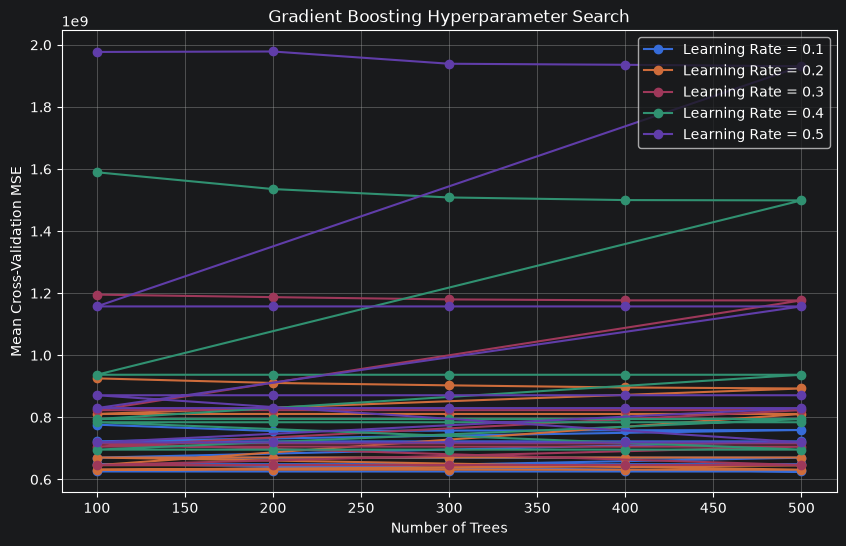

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for lr in sorted(results["param_learning_rate"].unique()):

    subset = results[
        results["param_learning_rate"] == lr
    ]

    plt.plot(
        subset["param_n_estimators"].astype(int),
        subset["mean_test_MSE"],
        marker="o",
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Number of Trees")
plt.ylabel("Mean Cross-Validation MSE")

plt.title(
    "Gradient Boosting Hyperparameter Search"
)

plt.legend()
plt.grid()

plt.show()

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
model=GradientBoostingRegressor(

    random_state=42
)

In [ ]:
param_distributions = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "max_depth": [1, 2, 3, 4, 5]
}

In [36]:
param_distributions = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "max_depth": [1, 2, 3, 4, 5]
}

random_search=RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=42,
    n_iter=20
)

In [37]:
random_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.03, ...], 'max_depth': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric eval

In [38]:
print("Best Parameters:")

print(
    random_search.best_params_
)

Best Parameters:
{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}


In [39]:
best_random_model = random_search.best_estimator_

print(best_random_model)

GradientBoostingRegressor(max_depth=4, n_estimators=300, random_state=42)


In [40]:
import pandas as pd

importance = best_random_model.feature_importances_

print(importance)
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance_df

[0.83833097 0.01488305 0.14678597]


,Feature,Importance
0,area,0.838331
1,bedrooms,0.014883
2,age,0.146786


In [43]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
0,area,0.838331
2,age,0.146786
1,bedrooms,0.014883


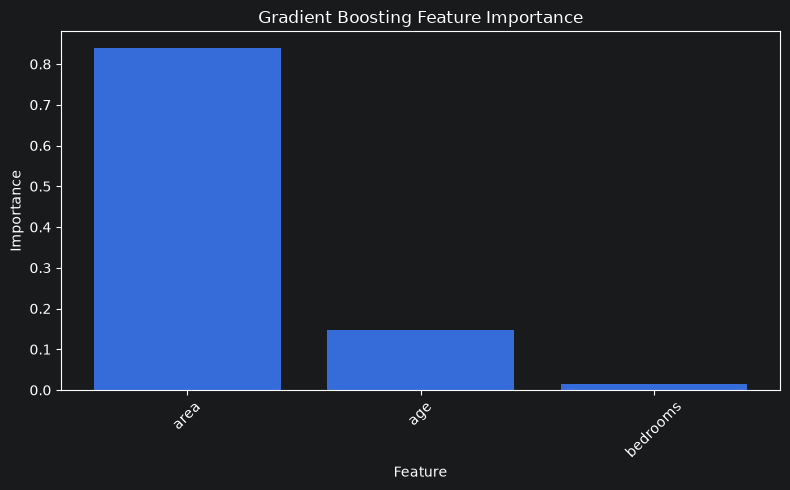

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")

plt.title(
    "Gradient Boosting Feature Importance"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()